# Benchmarking

In [1]:
import numpy as np
import importlib
import datasets
import sys
import torch
sys.path.insert(0, '/Users/gizemnurdal/Workspace/swim-meets-kans/pykan')
sys.path.insert(0, '/Users/gizemnurdal/Workspace/swim-meets-kans/sgkan')

importlib.reload(datasets)

from sklearn.linear_model import Ridge
from datasets import (
    load_dataset,
    min_max_scale_dataset
)

from hkan.hkan import (
    Sigmoid, Gaussian, ReLU, Tanh, Softplus, Identity,
    make_hkan_layer, extend_hkan, set_tqdm_disable,
)

from kan import KAN # type: ignore
from sgkan import surrogate_guided_kan as sgkan
from sgkan import gaussian_process_models as gp
from sgkan import gp_swim_like_pairs as gs
from sgkan import evaluation_metrics as em
from sklearn.metrics import root_mean_squared_error

torch.set_default_dtype(torch.float64)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cpu


## Utilities Functions

In [2]:
# ...existing code...
import time
import gpytorch

def build_hkan_from_params(model_params, tqdm_disable=False):
    """
    Build an HKAN model from a list of layer-param dicts.
    """
    # ensure sorted by layer index
    params = sorted(model_params, key=lambda p: int(p["layer"]))
    model = None
    set_tqdm_disable(tqdm_disable)  # keep consistent with notebook usage

    for p in params:
        layer_idx = int(p["layer"])
        n_vars_out = p["n_vars_out"]
        basis_fn = p["basis_fn"]
        n_basis = p.get("n_basis", 10)
        centers = p.get("centers", "random")
        reg = p.get("regressor", Ridge())

        if layer_idx == 0:
            model = make_hkan_layer(
                layer_idx=layer_idx,
                n_vars_out=n_vars_out,
                basis_fn=basis_fn,
                n_basis=n_basis,
                centers=centers,
                expanding_base_regressor=reg,
            )
        else:
            if model is None:
                raise ValueError("First layer (layer 0) must be provided before extending.")
            model = extend_hkan(
                model,
                layer_idx=layer_idx,
                n_vars_out=n_vars_out,
                basis_fn=basis_fn,
                n_basis=n_basis,
                centers=centers,
                expanding_base_regressor=reg,
            )
    return model

def fit_hkan(model, X_train, y_train):
    if model:
        start_time = time.time()
        model.fit(X_train, y_train)
        elapsed_time = time.time() - start_time
        print(f"\n✓ Training completed in {elapsed_time:.4f} seconds")

def predict_hkan(model, X_test):
    if model:
        start_time = time.time()
        predictions = model.predict(X_test)
        elapsed_time = time.time() - start_time
        print(f"✓ Prediction completed in {elapsed_time:.4f} seconds")
        return predictions

def build_kan(width, grid=3, k=3, seed=42):
    """Build a KAN model with specified architecture."""
    return KAN(width=width, grid=grid, k=k, seed=seed, device=device)

def fit_kan(model, X_train, y_train, X_test, y_test, steps=50, opt="LBFGS", lamb=0.01):
    """Train a KAN model with test data for validation."""
    start_time = time.time()
    X_train_tensor = torch.tensor(X_train, dtype=torch.float64, device=device)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float64, device=device)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float64, device=device)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float64, device=device)
    
    dataset = {
        'train_input': X_train_tensor, 
        'train_label': y_train_tensor,
        'test_input': X_test_tensor,
        'test_label': y_test_tensor
    }
    model.fit(dataset, opt=opt, steps=steps, lamb=lamb)
    
    elapsed_time = time.time() - start_time
    print(f"\n✓ Training completed in {elapsed_time:.4f} seconds")
    return model

def predict_kan(model, X_test):
    """Make predictions with a KAN model."""
    start_time = time.time()
    X_test_tensor = torch.tensor(X_test, dtype=torch.float64, device=device)
    predictions = model(X_test_tensor).detach().cpu().numpy()
    elapsed_time = time.time() - start_time
    print(f"✓ Prediction completed in {elapsed_time:.4f} seconds")
    return predictions

# ─── Kernel utilities ──────────────────────────────────────────
def create_rbf_kernel(input_dim):
    """Create RBF kernel with ARD (automatic relevance determination)."""
    return gpytorch.kernels.ScaleKernel(
        gpytorch.kernels.RBFKernel(ard_num_dims=input_dim)
    )

def create_matern_kernel(input_dim, nu=2.5):
    """Create Matern kernel with ARD."""
    return gpytorch.kernels.ScaleKernel(
        gpytorch.kernels.MaternKernel(nu=nu, ard_num_dims=input_dim)
    )

def create_rbf_matern_kernel(input_dim):
    """Create product of RBF and Matern kernels."""
    rbf = gpytorch.kernels.RBFKernel(ard_num_dims=input_dim)
    matern = gpytorch.kernels.MaternKernel(nu=2.5, ard_num_dims=input_dim)
    return gpytorch.kernels.ScaleKernel(rbf * matern)

def fit_sgkan(X_train, y_train, layer_configs, activation=torch.tanh, kernel=None):
    """Train SGKAN model with optional custom kernel."""
    start_time = time.time()
    X_train_tensor = torch.tensor(X_train, dtype=torch.float64)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float64)
    
    layers, W_out = sgkan.build_sgkan(X_train_tensor, y_train_tensor, layer_configs, activation=activation, kernel=kernel)
    
    elapsed_time = time.time() - start_time
    print(f"\n✓ Training completed in {elapsed_time:.4f} seconds")
    return layers, W_out

def predict_sgkan(layers, W_out, X_test, activation=torch.tanh):
    """Make predictions with SGKAN model."""
    start_time = time.time()
    X_test_tensor = torch.tensor(X_test, dtype=torch.float64)
    predictions = sgkan.predict_sgkan(layers, W_out, X_test_tensor, activation=activation).detach().numpy()
    elapsed_time = time.time() - start_time
    print(f"✓ Prediction completed in {elapsed_time:.4f} seconds")
    return predictions

def print_results(results):
    """Pretty-print evaluation results in a formatted table."""
    print(f"{'Metric':<15} {'Train':<20} {'Test':<20}")
    print("-" * 55)
    for metric in ['mae', 'rmse']:
        train_val = results['train'][metric]
        test_val = results['test'][metric]
        print(f"{metric.upper():<15} {train_val:<20.6e} {test_val:<20.6e}")

def plot_3d_surface(dataset_name, X_test, y_test, y_pred):
    """Plot 3D surface comparison of predicted vs actual values."""
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import Axes3D
    
    n_samples = len(X_test)
    grid_size = int(np.sqrt(n_samples))
    
    fig = plt.figure(figsize=(14, 6))
    
    X1 = X_test[:, 0].reshape(grid_size, grid_size)
    X2 = X_test[:, 1].reshape(grid_size, grid_size)
    
    ax = fig.add_subplot(121, projection="3d")
    ax.plot_surface(X1, X2, y_pred.reshape(grid_size, grid_size), cmap="viridis")
    ax.set_title(f"{dataset_name} - Predicted")
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")
    ax.set_zlabel("Y")
    
    ax = fig.add_subplot(122, projection="3d")
    ax.plot_surface(X1, X2, y_test.reshape(grid_size, grid_size), cmap="viridis")
    ax.set_title(f"{dataset_name} - Actual")
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")
    ax.set_zlabel("Y")
    
    plt.tight_layout()
    plt.show()

## TF1 RESULTS

### HKAN

In [3]:
# Load TF1 dataset
tf1 = load_dataset("TF1")
tf1_x_train, tf1_x_test, tf1_y_train, tf1_y_test = tf1["train_input"], tf1["test_input"], tf1["train_label"], tf1["test_label"]

In [4]:
print("TF1 X_train shape:", tf1_x_train.shape)
print("TF1 X_test shape:", tf1_x_test.shape)
print("TF1 y_train range:", tf1_y_train.min(), tf1_y_train.max())
print("TF1 y_train mean:", tf1_y_train.mean())

TF1 X_train shape: (5000, 2)
TF1 X_test shape: (10000, 2)
TF1 y_train range: 0.00926302338925278 0.98881776725053
TF1 y_train mean: 0.5053805775495802


In [5]:
# TF1 model params
tf1_model_params = [
    {
        "layer": 0,
        "n_vars_out": 932,
        "basis_fn": Sigmoid(s=1),
        "n_basis": 2,
        "centers": "random_data_points",
        "regressor": Ridge(alpha=0.1),
    },
    {
        "layer": 1,
        "n_vars_out": 1,
        "basis_fn": Tanh(s=33),
        "n_basis": 13,
        "centers": "random_data_points",
        "regressor": Ridge(alpha=10),
    }
]
tf1_model = build_hkan_from_params(tf1_model_params)
tf1_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('expanding_layer_0', ...), ('connecting_layer_0', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,n_vars_out,932
,n_basis,2
,centers,'random_data_points'
,basis_fn,<hkan.hkan.Si...t 0x17f5d2cd0>
,base_regressor,Ridge(alpha=0.1)
,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True


In [6]:
# Fit HKAN
fit_hkan(tf1_model,  tf1_x_train, tf1_y_train)
tf1_results = em.evaluate(
    tf1_model,
    tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test
)

Fitting connecting regressors: 100%|██████████| 1/1 [00:00<00:00,  2.66it/s]



✓ Training completed in 3.6221 seconds


In [7]:
print_results(tf1_results)

Metric          Train                Test                
-------------------------------------------------------
MAE             1.160632e-11         1.335211e-11        
RMSE            1.562178e-11         2.117703e-11        


In [8]:
tf1_y_test_pred = predict_hkan(tf1_model, tf1_x_test)

✓ Prediction completed in 2.3126 seconds


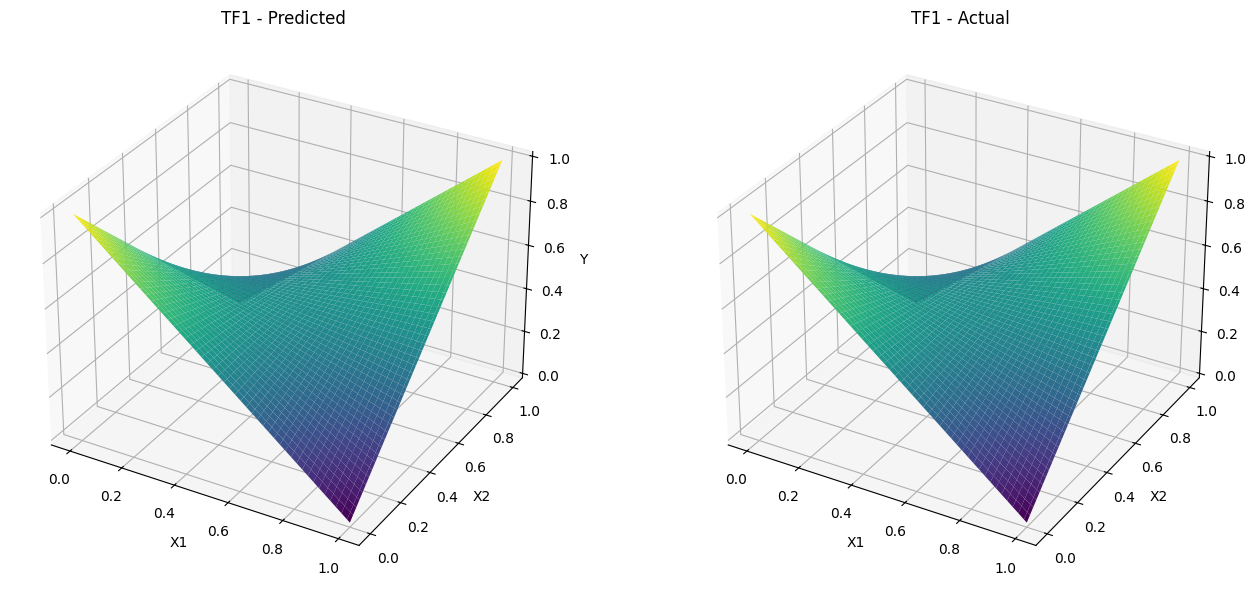

In [9]:
plot_3d_surface("TF1", tf1_x_test, tf1_y_test, tf1_y_test_pred)

### KAN

In [10]:
# Create TF1 KAN model with architecture [2, 5, 1]
tf1_kan_model = build_kan(width=[2, 5, 1], grid=3, k=3, seed=42)
print("TF1 KAN model created with architecture [2, 5, 1]")

checkpoint directory created: ./model
saving model version 0.0
TF1 KAN model created with architecture [2, 5, 1]


In [11]:
# Train TF1 KAN model
fit_kan(tf1_kan_model, tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test, steps=50, opt="Adam", lamb=0.01)

# Evaluate
tf1_y_train_pred_kan = tf1_kan_model(torch.tensor(tf1_x_train, dtype=torch.float64, device=device)).detach().cpu().numpy()
tf1_y_test_pred_kan_temp = tf1_kan_model(torch.tensor(tf1_x_test, dtype=torch.float64, device=device)).detach().cpu().numpy()

# Compute metrics manually for KAN
import torch as t
def compute_metrics(y_pred, y_true):
    y_pred_t = t.tensor(y_pred.flatten(), dtype=t.float64)
    y_true_t = t.tensor(y_true.flatten(), dtype=t.float64)
    mae = t.abs(y_pred_t - y_true_t).mean().item()
    rmse = t.sqrt(((y_pred_t - y_true_t) ** 2).mean()).item()
    return mae, rmse

train_mae, train_rmse = compute_metrics(tf1_y_train_pred_kan, tf1_y_train)
test_mae, test_rmse = compute_metrics(tf1_y_test_pred_kan_temp, tf1_y_test)

tf1_kan_results = {
    'train': {'mae': train_mae, 'rmse': train_rmse},
    'test': {'mae': test_mae, 'rmse': test_rmse}
}

| train_loss: 2.26e-01 | test_loss: 2.19e-01 | reg: 2.95e+01 | : 100%|█| 50/50 [00:12<00:00,  4.07it

saving model version 0.1

✓ Training completed in 12.2974 seconds


In [12]:
print_results(tf1_kan_results)

Metric          Train                Test                
-------------------------------------------------------
MAE             1.751828e-01         1.764411e-01        
RMSE            2.105851e-01         2.124250e-01        


In [13]:
tf1_y_test_pred_kan = predict_kan(tf1_kan_model, tf1_x_test)

✓ Prediction completed in 0.0158 seconds


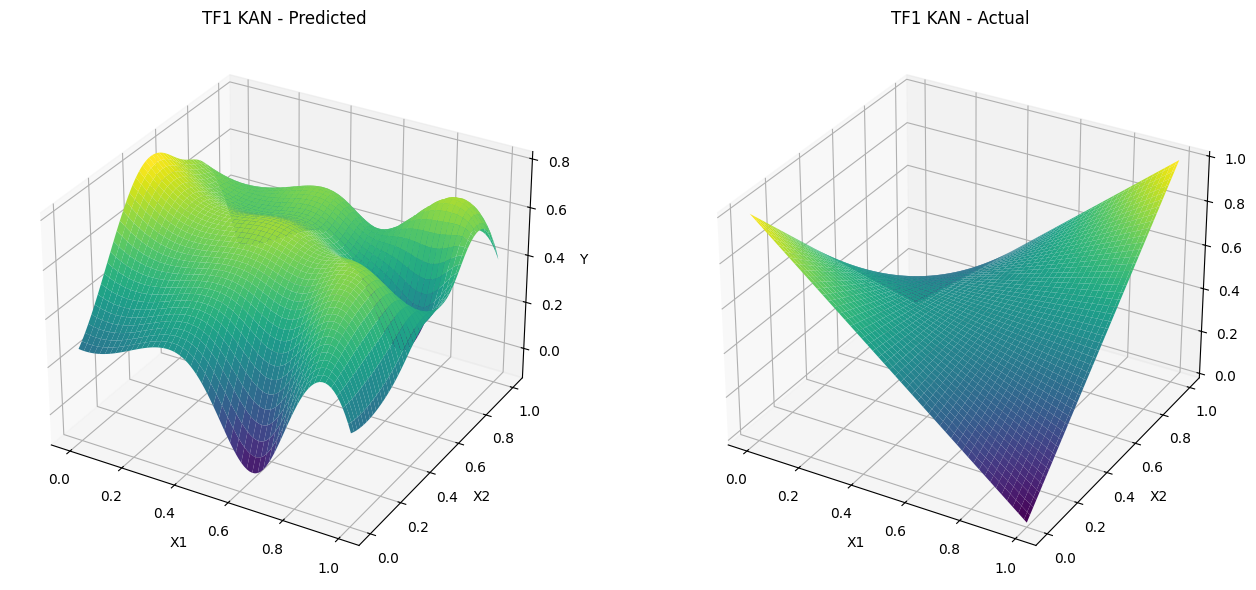

In [14]:
plot_3d_surface("TF1 KAN", tf1_x_test, tf1_y_test, tf1_y_test_pred_kan)

### SGKAN

In [15]:
# TF1 SGKAN layer configuration
# Single layer with width=5 to match KAN architecture
tf1_sgkan_layer_configs = [
    {"width": 128, "M": 500, "G": 50, "T": 10}
]

# Kernel options (available for use with gp.init_gp):
# - Default (RBF with ARD): passed implicitly
# - Custom Matern: kernel = create_matern_kernel(tf1_x_train.shape[1])
# - Custom RBF: kernel = create_rbf_kernel(tf1_x_train.shape[1])
# - Product: kernel = create_rbf_matern_kernel(tf1_x_train.shape[1])

# Train TF1 SGKAN (currently uses default RBF kernel)
# To use custom kernel, modify sgkan.build_sgkan to accept kernel parameter
tf1_sgkan_layers, tf1_sgkan_W_out = fit_sgkan(
    tf1_x_train, tf1_y_train, 
    tf1_sgkan_layer_configs,
    activation=torch.tanh,
    kernel=create_matern_kernel(tf1_x_train.shape[1])
)


─── Layer 1 | input: torch.Size([5000, 2]) ───
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([5000, 2]), num_inducing=500
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 100 iters, lr=0.1, loss=ELBO
  Iter 20/100, Loss: 0.767596
  Iter 40/100, Loss: 0.746958
  Iter 60/100, Loss: 0.742220
  Iter 80/100, Loss: 0.740938
  Iter 100/100, Loss: 0.740478
[DEBUG] Training complete.
  Lengthscale: tensor([[1.0856, 1.2848]])
  Outputscale: 0.2345
  Noise: 0.693247
  Mean const: 0.3078
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] Scores: min=0.0323, max=4.6247, mean=2.0747
[DEBUG] Probs:  min=0.000031,  max=0.004458,  sum=1.000000
[DEBUG] Selected 128 pairs from 500 candidates
[DEBUG] Unique pairs selected: 114 / 128
[DEBUG] x_segments shape:     torch.Size([128, 50, 2])
[DEBUG] edge_functions shape: torch.Size([128, 50])
[DEBUG] Value range: [0.1374, 0.8466]
[DEBUG] H shape: torch.Size([5000, 128])
[DEBUG] H value range

In [16]:
# Evaluate TF1 SGKAN
tf1_sgkan_y_train_pred = sgkan.predict_sgkan(tf1_sgkan_layers, tf1_sgkan_W_out, 
                                              torch.tensor(tf1_x_train, dtype=torch.float64),
                                              activation=torch.tanh).detach().numpy()
tf1_sgkan_y_test_pred_temp = sgkan.predict_sgkan(tf1_sgkan_layers, tf1_sgkan_W_out,
                                                   torch.tensor(tf1_x_test, dtype=torch.float64),
                                                   activation=torch.tanh).detach().numpy()

# Compute metrics
def compute_metrics(y_pred, y_true):
    y_pred_t = torch.tensor(y_pred.flatten(), dtype=torch.float64)
    y_true_t = torch.tensor(y_true.flatten(), dtype=torch.float64)
    mae = torch.abs(y_pred_t - y_true_t).mean().item()
    rmse = torch.sqrt(((y_pred_t - y_true_t) ** 2).mean()).item()
    return mae, rmse

train_mae, train_rmse = compute_metrics(tf1_sgkan_y_train_pred, tf1_y_train)
test_mae, test_rmse = compute_metrics(tf1_sgkan_y_test_pred_temp, tf1_y_test)

tf1_sgkan_results = {
    'train': {'mae': train_mae, 'rmse': train_rmse},
    'test': {'mae': test_mae, 'rmse': test_rmse}
}

[DEBUG] H shape: torch.Size([5000, 128])
[DEBUG] H value range: [0.1374, 0.8466]
[DEBUG] H rank (approx): 114
[DEBUG] H shape: torch.Size([10000, 128])
[DEBUG] H value range: [0.1374, 0.8466]
[DEBUG] H rank (approx): 114


In [17]:
print_results(tf1_sgkan_results)

Metric          Train                Test                
-------------------------------------------------------
MAE             2.710999e-03         2.914888e-03        
RMSE            3.847142e-03         4.304871e-03        


In [18]:
tf1_sgkan_y_test_pred = predict_sgkan(tf1_sgkan_layers, tf1_sgkan_W_out, tf1_x_test, activation=torch.tanh)

[DEBUG] H shape: torch.Size([10000, 128])
[DEBUG] H value range: [0.1374, 0.8466]
[DEBUG] H rank (approx): 114
✓ Prediction completed in 0.0431 seconds


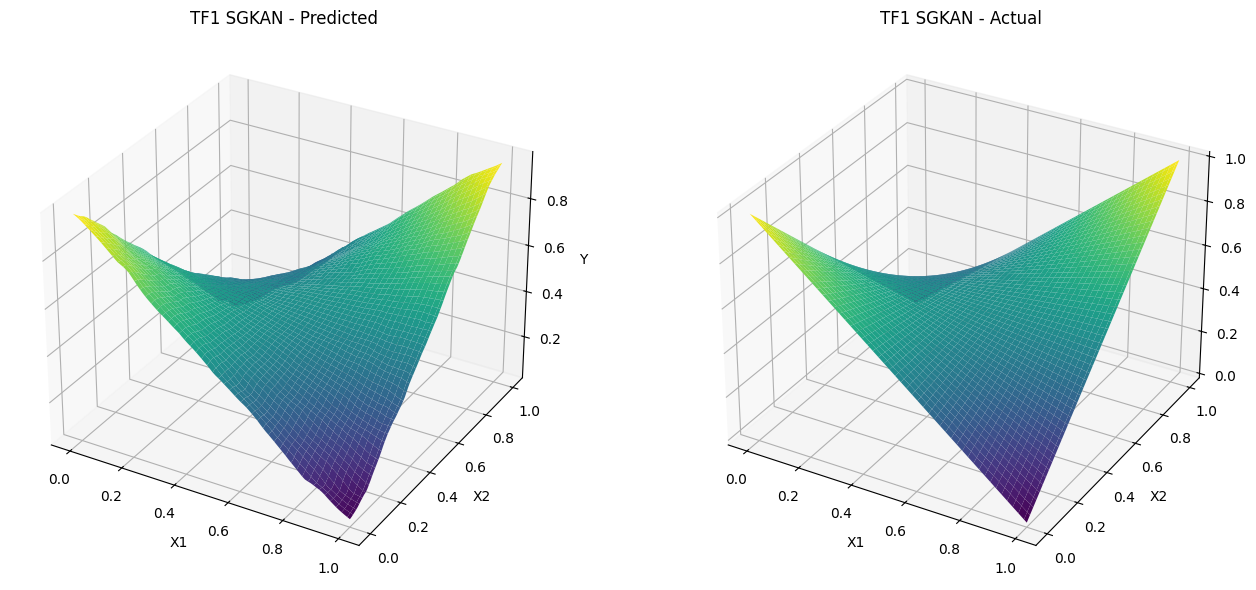

In [19]:
plot_3d_surface("TF1 SGKAN", tf1_x_test, tf1_y_test, tf1_sgkan_y_test_pred)

## TF5 Results

### HKAN

In [20]:
# Load tf5 dataset
tf5 = load_dataset("TF5")
tf5_x_train, tf5_x_test, tf5_y_train, tf5_y_test = tf5["train_input"], tf5["test_input"], tf5["train_label"], tf5["test_label"]

In [21]:
print("TF5 X_train shape:", tf5_x_train.shape)
print("TF5 X_test shape:", tf5_x_test.shape)
print("TF5 y_train range:", tf5_y_train.min(), tf5_y_train.max())
print("TF5 y_train mean:", tf5_y_train.mean())

TF5 X_train shape: (5000, 2)
TF5 X_test shape: (10000, 2)
TF5 y_train range: 0.00793312578437663 1.0
TF5 y_train mean: 0.8847614396547168


In [22]:
# TF5 model params
tf5_model_params = [
    {
        "layer": 0,
        "n_vars_out": 912,
        "basis_fn": Tanh(s=50),
        "n_basis": 23,
        "centers": "random_data_points",
        "regressor": Ridge(alpha=0.01),
    },
    {
        "layer": 1,
        "n_vars_out": 1,
        "basis_fn": Identity(),
        "n_basis": 10,
        "centers": "random_data_points",
        "regressor": Ridge(alpha=0.1),
    }
]
tf5_model = build_hkan_from_params(tf5_model_params)
tf5_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('expanding_layer_0', ...), ('connecting_layer_0', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,n_vars_out,912
,n_basis,23
,centers,'random_data_points'
,basis_fn,<hkan.hkan.Ta...t 0x31f773310>
,base_regressor,Ridge(alpha=0.01)
,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",0.01
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True


In [23]:
# Fit HKAN
fit_hkan(tf5_model, tf5_x_train, tf5_y_train)
tf5_results = em.evaluate(
    tf5_model,
    tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test
)

Fitting connecting regressors: 100%|██████████| 1/1 [00:00<00:00,  3.07it/s]



✓ Training completed in 7.0110 seconds


In [24]:
print_results(tf5_results)

Metric          Train                Test                
-------------------------------------------------------
MAE             5.898358e-13         7.448443e-13        
RMSE            7.326997e-13         1.233418e-12        


In [25]:
tf5_y_test_pred = predict_hkan(tf5_model, tf5_x_test)

✓ Prediction completed in 5.0481 seconds


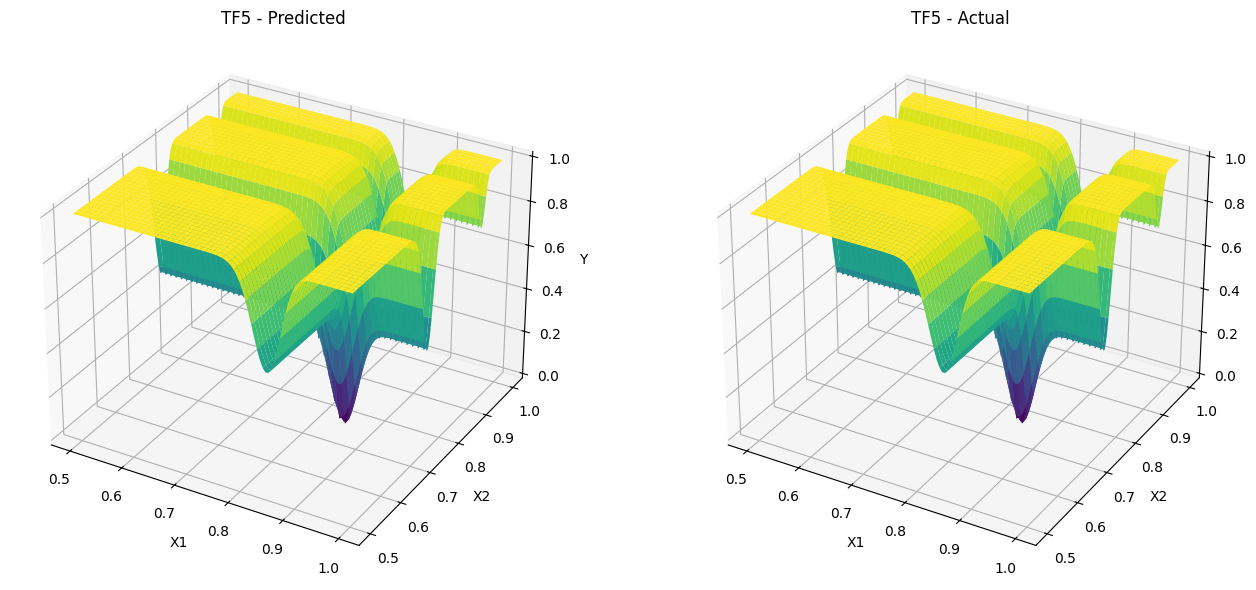

In [26]:
plot_3d_surface("TF5", tf5_x_test, tf5_y_test, tf5_y_test_pred)

### KAN

In [27]:
# Create TF5 KAN model with architecture [2, 5, 1]
tf5_kan_model = build_kan(width=[2, 5, 1], grid=3, k=3, seed=42)
print("TF5 KAN model created with architecture [2, 5, 1]")

checkpoint directory created: ./model
saving model version 0.0
TF5 KAN model created with architecture [2, 5, 1]


In [28]:
# Train TF5 KAN model
fit_kan(tf5_kan_model, tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test, steps=50, opt="LBFGS", lamb=0.01)

# Evaluate
tf5_y_train_pred_kan = tf5_kan_model(torch.tensor(tf5_x_train, dtype=torch.float64, device=device)).detach().cpu().numpy()
tf5_y_test_pred_kan_temp = tf5_kan_model(torch.tensor(tf5_x_test, dtype=torch.float64, device=device)).detach().cpu().numpy()

# Compute metrics
train_mae, train_rmse = compute_metrics(tf5_y_train_pred_kan, tf5_y_train)
test_mae, test_rmse = compute_metrics(tf5_y_test_pred_kan_temp, tf5_y_test)

tf5_kan_results = {
    'train': {'mae': train_mae, 'rmse': train_rmse},
    'test': {'mae': test_mae, 'rmse': test_rmse}
}

| train_loss: 1.77e-01 | test_loss: 1.79e-01 | reg: 4.80e-01 | : 100%|█| 50/50 [02:12<00:00,  2.65s/

saving model version 0.1

✓ Training completed in 132.4624 seconds


In [29]:
print_results(tf5_kan_results)

Metric          Train                Test                
-------------------------------------------------------
MAE             1.400366e-01         1.413504e-01        
RMSE            1.771899e-01         1.791938e-01        


In [30]:
tf5_y_test_pred_kan = predict_kan(tf5_kan_model, tf5_x_test)

✓ Prediction completed in 0.0174 seconds


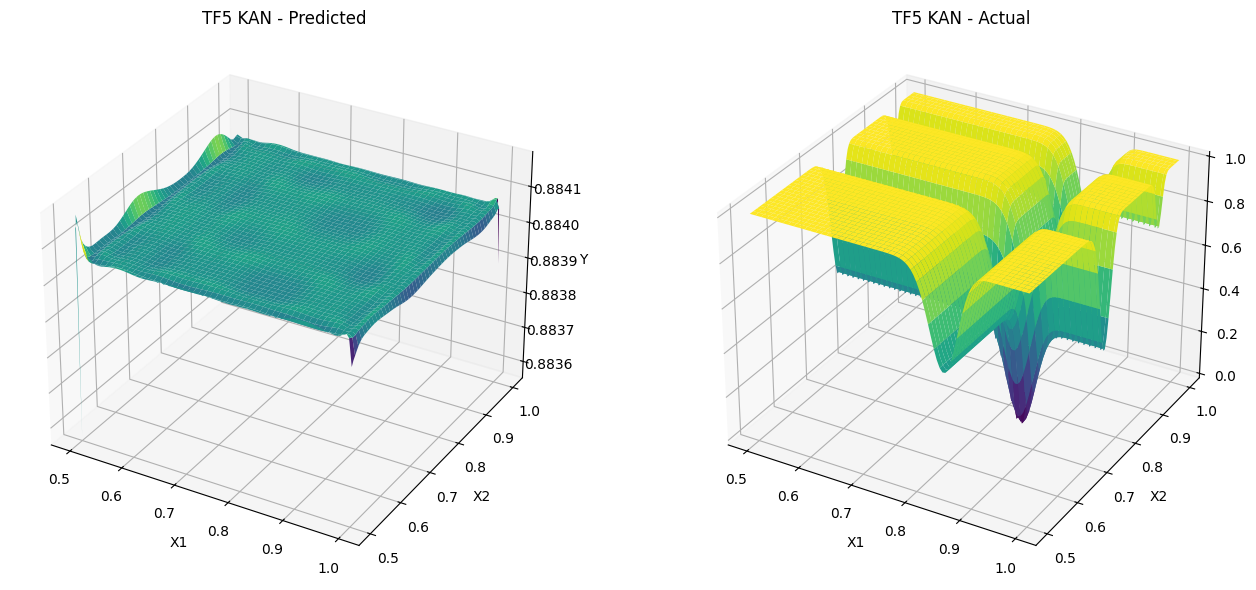

In [31]:
plot_3d_surface("TF5 KAN", tf5_x_test, tf5_y_test, tf5_y_test_pred_kan)

### SGKAN

In [57]:
# TF5 SGKAN layer configuration
tf5_sgkan_layer_configs = [
    {"width": 128, "M": 5000, "G": 50, "T": 10}
]

# Kernel options (available for use with gp.init_gp):
# - Default (RBF with ARD): passed implicitly
# - Custom Matern: kernel = create_matern_kernel(tf5_x_train.shape[1])
# - Custom RBF: kernel = create_rbf_kernel(tf5_x_train.shape[1])
# - Product: kernel = create_rbf_matern_kernel(tf5_x_train.shape[1])

# Train TF5 SGKAN (currently uses default RBF kernel)
# To use custom kernel, modify sgkan.build_sgkan to accept kernel parameter
tf5_sgkan_layers, tf5_sgkan_W_out = fit_sgkan(
    tf5_x_train, tf5_y_train, 
    tf5_sgkan_layer_configs, 
    activation=torch.tanh,
    kernel=create_matern_kernel(tf5_x_train.shape[1])
)


─── Layer 1 | input: torch.Size([5000, 2]) ───
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([5000, 2]), num_inducing=500
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 100 iters, lr=0.1, loss=ELBO
  Iter 20/100, Loss: 0.772665
  Iter 40/100, Loss: 0.762370
  Iter 60/100, Loss: 0.759123
  Iter 80/100, Loss: 0.758515
  Iter 100/100, Loss: 0.758268
[DEBUG] Training complete.
  Lengthscale: tensor([[1.1176, 1.0575]])
  Outputscale: 0.1840
  Noise: 0.693247
  Mean const: 0.6263
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] Scores: min=0.0125, max=3.5634, mean=1.4393
[DEBUG] Probs:  min=0.000002,  max=0.000495,  sum=1.000000
[DEBUG] Selected 128 pairs from 5000 candidates
[DEBUG] Unique pairs selected: 128 / 128
[DEBUG] x_segments shape:     torch.Size([128, 50, 2])
[DEBUG] edge_functions shape: torch.Size([128, 50])
[DEBUG] Value range: [0.8187, 0.9931]
[DEBUG] H shape: torch.Size([5000, 128])
[DEBUG] H value rang

In [58]:
# Evaluate TF5 SGKAN
tf5_sgkan_y_train_pred = sgkan.predict_sgkan(tf5_sgkan_layers, tf5_sgkan_W_out, 
                                              torch.tensor(tf5_x_train, dtype=torch.float64),
                                              activation=torch.tanh).detach().numpy()
tf5_sgkan_y_test_pred_temp = sgkan.predict_sgkan(tf5_sgkan_layers, tf5_sgkan_W_out,
                                                   torch.tensor(tf5_x_test, dtype=torch.float64),
                                                   activation=torch.tanh).detach().numpy()

# Compute metrics
train_mae, train_rmse = compute_metrics(tf5_sgkan_y_train_pred, tf5_y_train)
test_mae, test_rmse = compute_metrics(tf5_sgkan_y_test_pred_temp, tf5_y_test)

tf5_sgkan_results = {
    'train': {'mae': train_mae, 'rmse': train_rmse},
    'test': {'mae': test_mae, 'rmse': test_rmse}
}

[DEBUG] H shape: torch.Size([5000, 128])
[DEBUG] H value range: [0.8187, 0.9931]
[DEBUG] H rank (approx): 128
[DEBUG] H shape: torch.Size([10000, 128])
[DEBUG] H value range: [0.8187, 0.9931]
[DEBUG] H rank (approx): 128


In [59]:
print_results(tf5_sgkan_results)

Metric          Train                Test                
-------------------------------------------------------
MAE             5.999217e-02         6.208335e-02        
RMSE            7.676727e-02         7.964485e-02        


In [60]:
tf5_sgkan_y_test_pred = predict_sgkan(tf5_sgkan_layers, tf5_sgkan_W_out, tf5_x_test, activation=torch.tanh)

[DEBUG] H shape: torch.Size([10000, 128])
[DEBUG] H value range: [0.8187, 0.9931]
[DEBUG] H rank (approx): 128
✓ Prediction completed in 0.0433 seconds


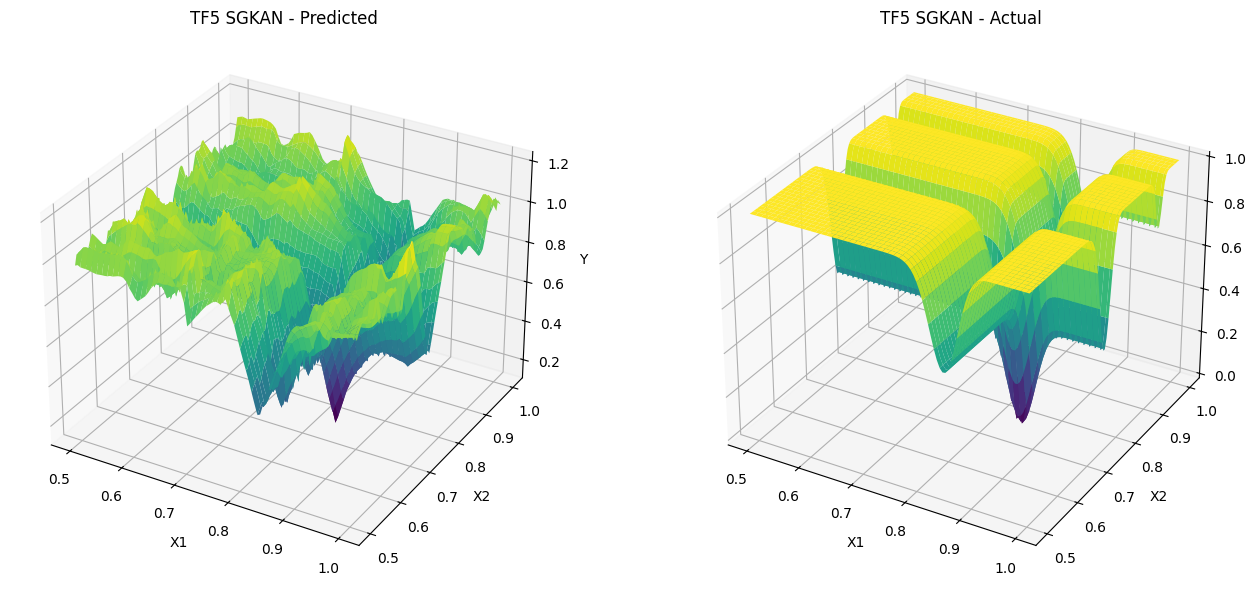

In [61]:
plot_3d_surface("TF5 SGKAN", tf5_x_test, tf5_y_test, tf5_sgkan_y_test_pred)